#### Problem Statement 
The banking churn prediction dataset contains different attributes of the customers of the bank and whether they have churned or not.

Goal of this analysis
- Understand the features
- Identify and quantify the features which contributes to churning
- Discover patterns of features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset, datatypes and null value

In [2]:
customers = pd.read_csv("Banking_churn_prediction.csv").drop("customer_id", axis=1) # dropping customer id as it is not useful for analysis

In [3]:
customers.head()

,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [4]:
no_sample,no_features = customers.shape
print(f"The customer dataset contains {no_sample} samples and {no_features} features")


The customer dataset contains 28382 samples and 20 features


In [5]:
### Check for Null values and data types of features

In [6]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   vintage                         28382 non-null  int64  
 1   age                             28382 non-null  int64  
 2   gender                          27857 non-null  object 
 3   dependents                      25919 non-null  float64
 4   occupation                      28302 non-null  object 
 5   city                            27579 non-null  float64
 6   customer_nw_category            28382 non-null  int64  
 7   branch_code                     28382 non-null  int64  
 8   current_balance                 28382 non-null  float64
 9   previous_month_end_balance      28382 non-null  float64
 10  average_monthly_balance_prevQ   28382 non-null  float64
 11  average_monthly_balance_prevQ2  28382 non-null  float64
 12  current_month_credit            

In [7]:
customers["last_transaction"] = pd.to_datetime(customers["last_transaction"])

In [8]:
object_columns = customers.select_dtypes(include='object').columns.to_list()
numerical_features = customers.select_dtypes(include='number').columns.to_list()
date_columns = customers.select_dtypes(include='datetime').columns.to_list()

print(f"Total Columns: {len(customers.columns.to_list())}\n")
print(f"Number of object columns: {len(object_columns)},\nColumns: {object_columns}\n")
print(f"Number of Numerical features: {len(numerical_features)},\nColumns: {numerical_features}\n")

print(f"Number of Datetime columns: {len(date_columns)},\nColumns: {date_columns}\n")



Total Columns: 20

Number of object columns: 2,
Columns: ['gender', 'occupation']

Number of Numerical features: 17,
Columns: ['vintage', 'age', 'dependents', 'city', 'customer_nw_category', 'branch_code', 'current_balance', 'previous_month_end_balance', 'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2', 'current_month_credit', 'previous_month_credit', 'current_month_debit', 'previous_month_debit', 'current_month_balance', 'previous_month_balance', 'churn']

Number of Datetime columns: 1,
Columns: ['last_transaction']



In [9]:
numerical_columns = ['vintage', 'age', 'current_balance', 'previous_month_end_balance', 'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2', 'current_month_credit', 'previous_month_credit', 'current_month_debit', 'previous_month_debit', 'current_month_balance', 'previous_month_balance']
numerical_columns

['vintage',
 'age',
 'current_balance',
 'previous_month_end_balance',
 'average_monthly_balance_prevQ',
 'average_monthly_balance_prevQ2',
 'current_month_credit',
 'previous_month_credit',
 'current_month_debit',
 'previous_month_debit',
 'current_month_balance',
 'previous_month_balance']

In [10]:
### percentage of null values for Null columns

In [11]:
for col in customers.columns:
    if customers[col].isnull().sum() != 0:
        print(f"Column '{col}' has {customers[col].isnull().sum()} null values, {np.round(customers[col].isnull().mean() * 100, 2)}% of total samples")

Column 'gender' has 525 null values, 1.85% of total samples
Column 'dependents' has 2463 null values, 8.68% of total samples
Column 'occupation' has 80 null values, 0.28% of total samples
Column 'city' has 803 null values, 2.83% of total samples
Column 'last_transaction' has 3223 null values, 11.36% of total samples


In [12]:
null_columns = customers.columns[customers.isna().any()].to_list()
print(f"Number of Null Columns: {len(null_columns)}, columns: {null_columns}")

Number of Null Columns: 5, columns: ['gender', 'dependents', 'occupation', 'city', 'last_transaction']


### __Insight - 1__
- __The customer dataset contains 28,382 samples and 20 features, only 5 columns contains null values ('gender', 'dependents', 'occupation', 'city', 'last_transaction')__

    - 'gender' has 525 null values, 1.85% of total samples
    - 'dependents' has 2463 null values, 8.68% of total samples
    - 'occupation' has 80 null values, 0.28% of total samples
    - 'city' has 803 null values, 2.83% of total samples
    - 'last_transaction' has 3223 null values, 11.36% of total samples

### categorical and Numerical feature - Univariate Analysis

In [13]:
customers[numerical_columns].describe()

,vintage,age,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance
count,28382.000000,28382.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04
mean,2091.144105,48.208336,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03
std,272.676775,17.807163,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04
min,73.000000,1.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03
25%,1958.000000,36.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03
50%,2154.000000,46.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03
75%,2292.000000,60.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03
max,2476.000000,90.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06


In [14]:
### Categorical Features Analysis - value Counts

In [15]:
categorical_columns = ["gender", "occupation", "customer_nw_category", "dependents", "city", "branch_code"]
for col in categorical_columns:
    print(f"{customers[col].value_counts()}\n")

gender
Male      16548
Female    11309
Name: count, dtype: int64

occupation
self_employed    17476
salaried          6704
student           2058
retired           2024
company             40
Name: count, dtype: int64

customer_nw_category
2    14559
3    10112
1     3711
Name: count, dtype: int64

dependents
0.0     21435
2.0      2150
1.0      1395
3.0       701
4.0       179
5.0        41
6.0         8
7.0         3
9.0         1
52.0        1
36.0        1
50.0        1
8.0         1
25.0        1
32.0        1
Name: count, dtype: int64

city
1020.0    3479
1096.0    2016
409.0     1334
146.0     1291
834.0     1138
          ... 
748.0        1
1099.0       1
108.0        1
655.0        1
723.0        1
Name: count, Length: 1604, dtype: int64

branch_code
19      145
6       142
60      128
16      111
8       109
       ... 
3690      1
2569      1
4017      1
4264      1
4104      1
Name: count, Length: 3185, dtype: int64



In [16]:
### Univariate Analysis

In [17]:
target = "churn"

In [18]:
#### Numerical columns

In [19]:
def plot_histogram(column, bins=20):
    min_value = customers[column].min()
    max_value = customers[column].max()
    print(f"Column: {column}: min value : {min_value}, max value: {max_value}")
    plt.hist(customers[column], bins=bins, edgecolor='black')
    #sns.histplot(data=customers, x = column, hue=target)
    plt.xlim(min_value, max_value)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")
    plt.show()

In [20]:
import statistics as stat
from scipy.stats import kurtosis

def measure_skewness(x):
    if x.isna().sum() > 0:
        x.fillna(0, inplace=True)
    #print(x.isna().sum())

    x_mean = x.mean()
    x_mode = stat.mode(x)
    x_std = x.std()

    q1, q2, q3 = stat.quantiles(x)
    
    try:
        sk_1 = (x_mean - x_mode)/x_std
        sk_2 = 3*(x_mean - q2) / x_std
        if (q3 - q1) !=0:
            sk_b = (q1 + q3 - 2*q2) / (q3 - q1)
        else:
            sk_b = sk_1

        print(f"Pearson's First coefficient of Skewness(SK1): {np.round(sk_1, 2)},\n"
            f"Pearson's Second coefficient of Skewness(SK2): {np.round(sk_2, 2)},\n"
            f"Bowley's coefficient of Skewness(SKB): {np.round(sk_b, 2)}")

        print()

        if -0.5 < sk_1 < 0.5:
            print("The distribution is approximately symmetric")
        elif -1.0 < sk_1 < -0.5 or 0.5 < sk_1 < 1:
            print("The distribution is moderately skewed")
        elif 1 < sk_1 < -1:
            print("Highly skewed")
        
        
        if sk_b == 0:
            #print(f"Column '{x.name}' is symmetric")
            skeweness = "symmetric"
        elif sk_b > 0:
            #print(f"Column '{x.name}' is Right Skewed")
            skeweness = "right"
        else:
            #print(f"Column '{x.name}' is left Skewed")
            skeweness = "left"
    except ZeroDivisionError as err:
        print(err)
    except Exception as e:
        print(e)
    
    excess_kurtosis = kurtosis(x) 

    print(f"excess kurtosis: {np.round(excess_kurtosis, 2)}")

    if excess_kurtosis > 0:
        # leptokurtic
        prob_outliers = "high"
    elif excess_kurtosis < 0:
        # platykurtic
        prob_outliers = "low"
    else:
        # mesokurtic
        prob_outliers = "none"

    return prob_outliers, skeweness


In [21]:
##### Check skeweness of Numerical features

In [22]:

number_columns = ["vintage", "age", "current_balance", "previous_month_end_balance", "average_monthly_balance_prevQ", "average_monthly_balance_prevQ2", "current_month_credit", "previous_month_credit", "current_month_debit", "previous_month_debit", "current_month_balance", "previous_month_balance"]

outliers = dict()

for col in number_columns: 
    print(f"Column: {col}\n")
    prob_outliers,skeweness = measure_skewness(customers[col])

    if prob_outliers in outliers.keys():
        outliers[prob_outliers].append(col)
    else:
        outliers[prob_outliers] = [col]
    print(f"probability of outliers: {prob_outliers}, Skeweness: {skeweness}")
    print("="*50)

Column: vintage

Pearson's First coefficient of Skewness(SK1): -0.62,
Pearson's Second coefficient of Skewness(SK2): -0.69,
Bowley's coefficient of Skewness(SKB): -0.17

The distribution is moderately skewed
excess kurtosis: 2.72
probability of outliers: high, Skeweness: left
Column: age

Pearson's First coefficient of Skewness(SK1): -2.35,
Pearson's Second coefficient of Skewness(SK2): 0.37,
Bowley's coefficient of Skewness(SKB): 0.15

excess kurtosis: -0.17
probability of outliers: low, Skeweness: right
Column: current_balance

Pearson's First coefficient of Skewness(SK1): 0.14,
Pearson's Second coefficient of Skewness(SK2): 0.29,
Bowley's coefficient of Skewness(SKB): 0.38

The distribution is approximately symmetric
excess kurtosis: 13090.05
probability of outliers: high, Skeweness: right
Column: previous_month_end_balance

Pearson's First coefficient of Skewness(SK1): 0.14,
Pearson's Second coefficient of Skewness(SK2): 0.29,
Bowley's coefficient of Skewness(SKB): 0.38

The distri

In [23]:
print(f"Low probability of outliers: {outliers.get("low")}, high probability of outliers: {outliers.get("high")}")

Low probability of outliers: ['age'], high probability of outliers: ['vintage', 'current_balance', 'previous_month_end_balance', 'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2', 'current_month_credit', 'previous_month_credit', 'current_month_debit', 'previous_month_debit', 'current_month_balance', 'previous_month_balance']


### Insight - 2 

- __numerical features contains high number of outliers except 'age'__
    - 'vintage',
    - 'current_balance',
    - 'previous_month_end_balance',
    - 'average_monthly_balance_prevQ',
    - 'average_monthly_balance_prevQ2',
    - 'current_month_credit',
    - 'previous_month_credit',
    -  'current_month_debit',
    - 'previous_month_debit',
    -  'current_month_balance',
    -  'previous_month_balance'

### Categorical feature distribution

In [24]:
def plot_barplt(column):
    plt.figure(figsize=(14,8))
    counts = round(customers[column].value_counts(normalize="true")*100, 2)
    ax = counts.plot(kind='bar')
    ax.bar_label(ax.containers[0])
    plt.title(f"Distribution of '{column}'")
    plt.xlabel(f"{column}")
    plt.ylabel(f"Count")
    plt.show()

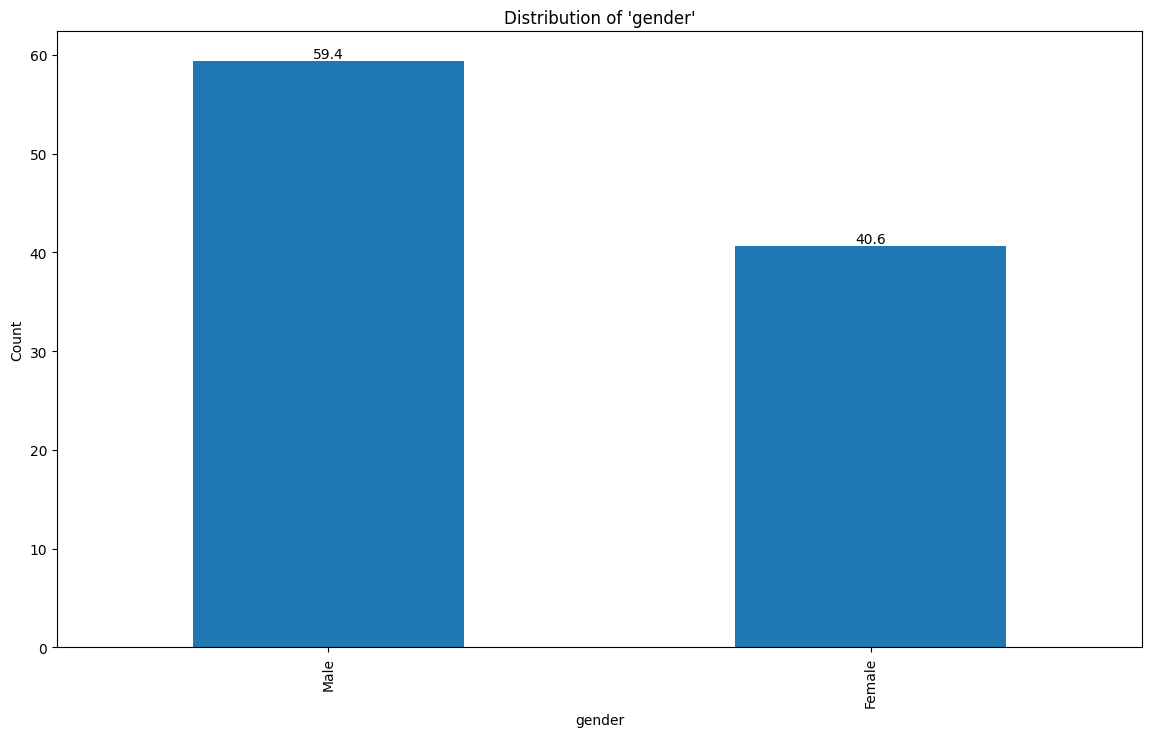

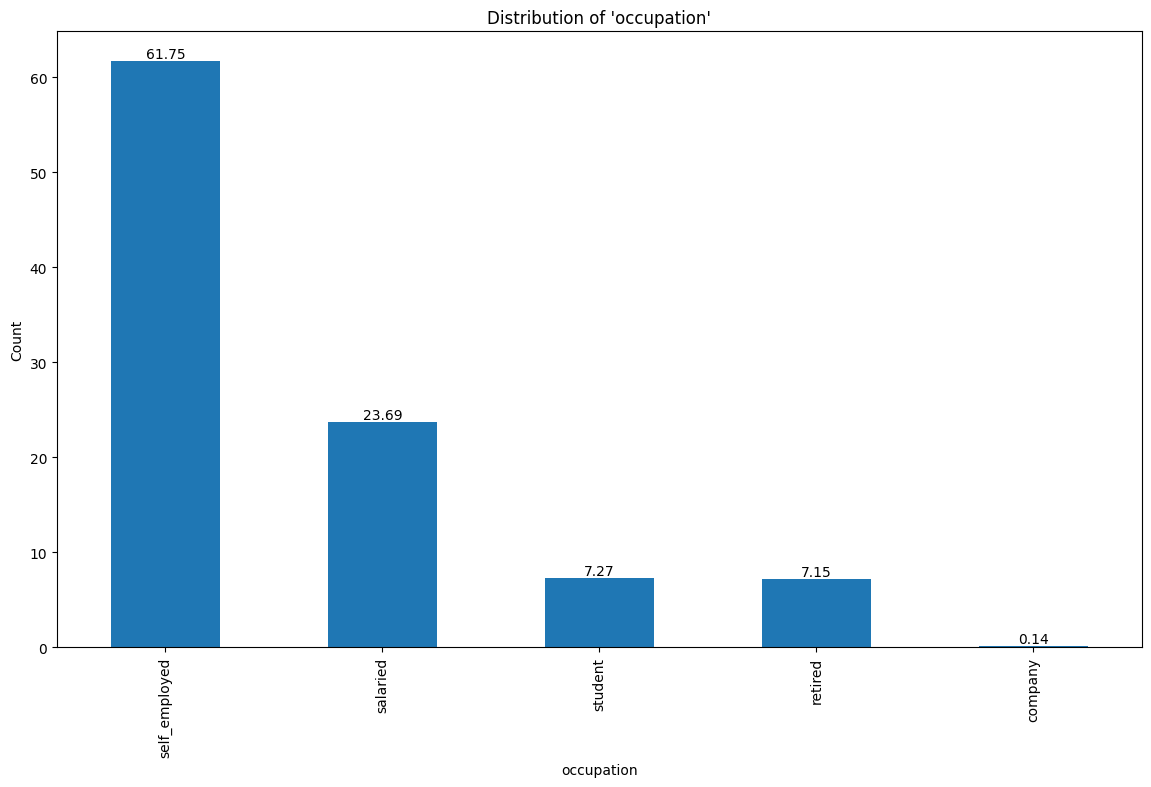

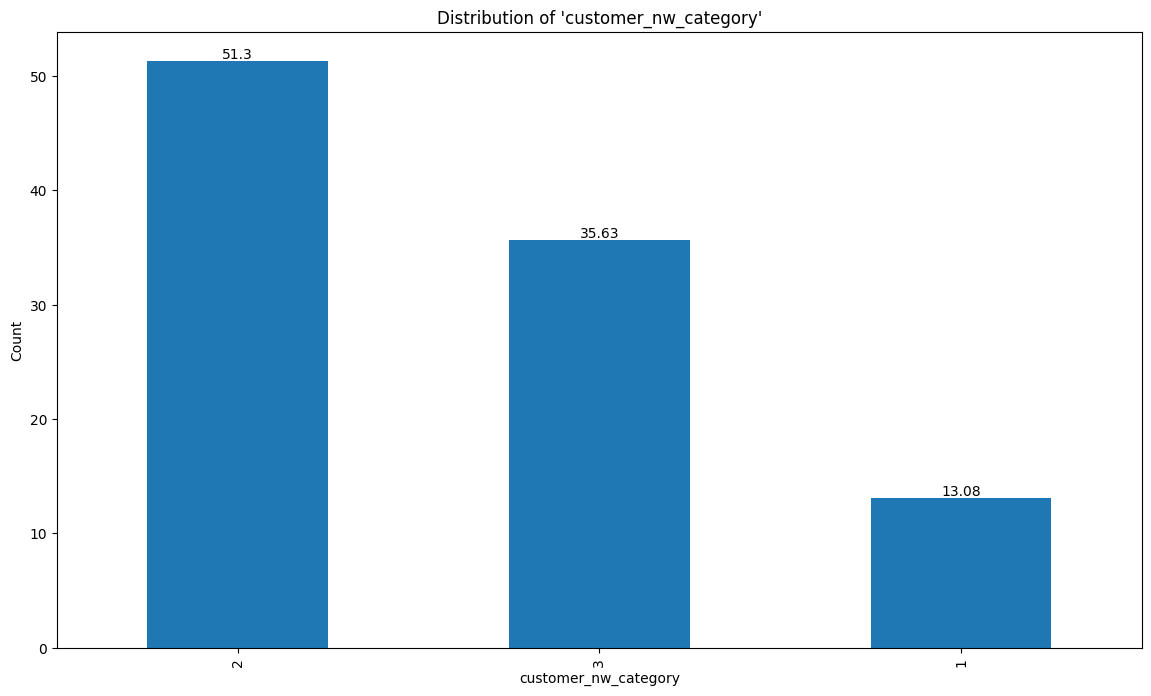

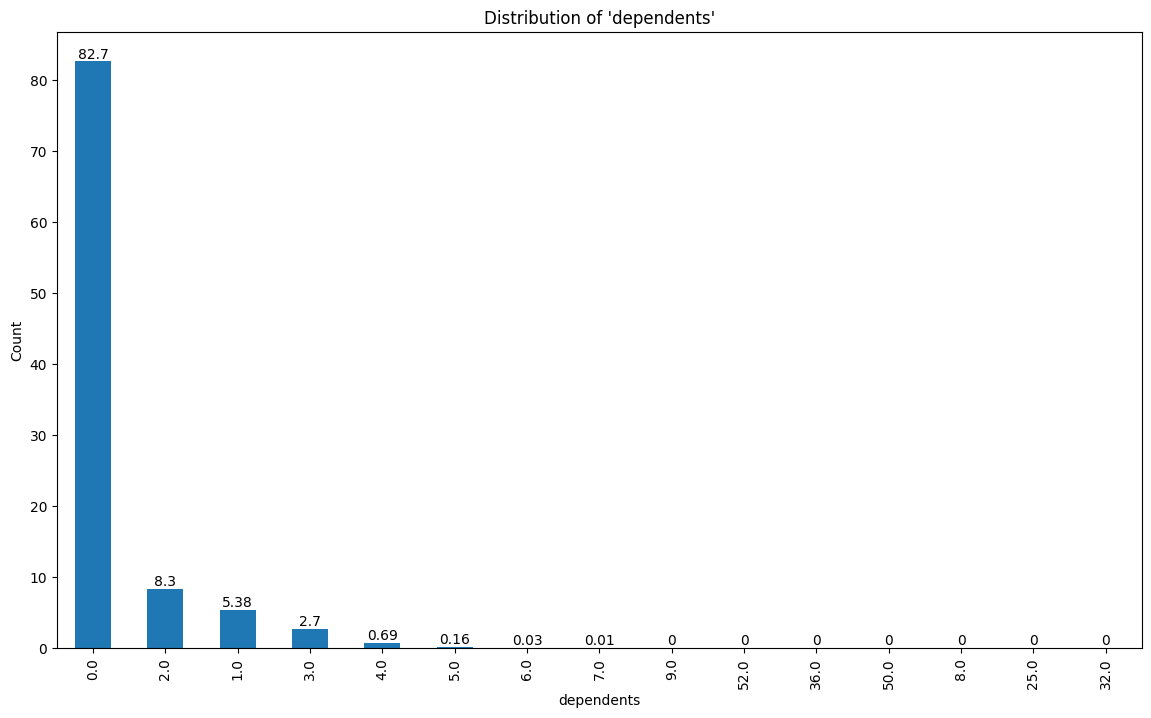

In [25]:
cat_cols = ["gender", "occupation", "customer_nw_category", "dependents"]
for col in cat_cols:
    plot_barplt(col)

In [26]:
top_5_city = (round(customers["city"].value_counts(normalize=True)*100, 2)).head(5).to_dict()

for k,v in top_5_city.items():
    print(f"{v}% customers are from {int(k)} city")

12.61% customers are from 1020 city
7.31% customers are from 1096 city
4.84% customers are from 409 city
4.68% customers are from 146 city
4.13% customers are from 834 city


In [27]:
top_5_branch_code = (round(customers["branch_code"].value_counts(normalize=True)*100, 2)).head(5).to_dict()

for k,v in top_5_branch_code.items():
    print(f"{v}% customers are from branch-code {int(k)}")

0.51% customers are from branch-code 19
0.5% customers are from branch-code 6
0.45% customers are from branch-code 60
0.39% customers are from branch-code 16
0.38% customers are from branch-code 8


Text(0.5, 1.0, 'Top 5 City vs churn')

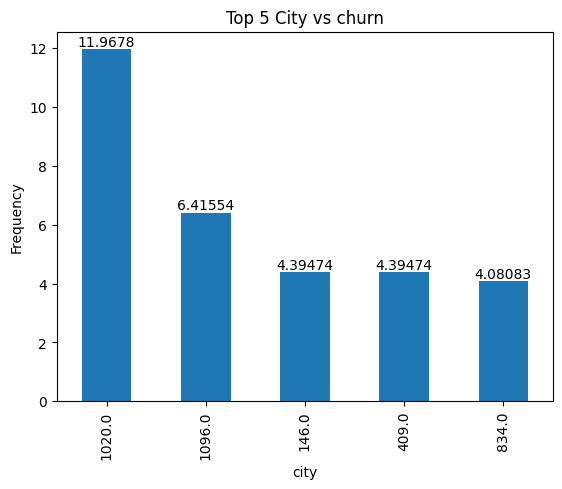

In [28]:
ax = (customers[customers["churn"] == 1]["city"].value_counts(normalize=True)*100).head(5).plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.ylabel("Frequency")
plt.title("Top 5 City vs churn")

Text(0.5, 1.0, 'Top 5 branch_code vs churn')

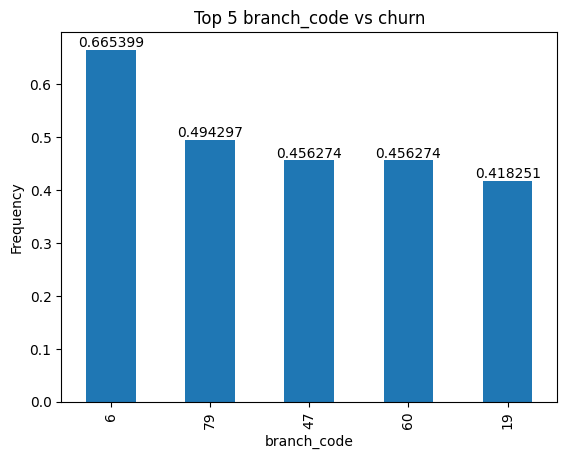

In [29]:
ax = (customers[customers["churn"] == 1]["branch_code"].value_counts(normalize=True)*100).head(5).plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.ylabel("Frequency")
plt.title("Top 5 branch_code vs churn")

### Insight - 3

- __Category feature distribution__
    - 'gender'- 59.4% is male and 40.59 % is female
    - 'self-employed' - 61% is self-employed
    - 'customer_nw_category' - 51.29% in category 2
    
    - 'city' 
        - 12.26% customers are from 1020 city
        - 7.1% customers are from 1096 city
        - 4.7% customers are from 409 city
        - 4.55% customers are from 146 city
        - 4.01% customers are from 834 city

    - 'branch code'
        - 0.51% customers are from branch-code 19
        - 0.5% customers are from branch-code 6
        - 0.45% customers are from branch-code 60
        - 0.39% customers are from branch-code 16
        - 0.38% customers are from branch-code 8

    - 'dependents'
        -82% customers has 0 dependents

### Bivariant Analysis ### Categorical Column vs. Target

In [30]:
churned_customers = customers["churn"].value_counts(normalize=True)*100
print(f"{round(churned_customers[1],2)}% customers closed their account")

18.53% customers closed their account


In [31]:
def get_churn_top_5(col):
    churn_top_5 = (round(customers[customers["churn"] == 1][col].value_counts(normalize=True)*100, 2)).head(5).to_dict()

    for k,v in churn_top_5.items():
        print(f"{v}% customers closed their account are from {int(k)} {col}")

In [32]:
get_churn_top_5("city")

11.97% customers closed their account are from 1020 city
6.42% customers closed their account are from 1096 city
4.39% customers closed their account are from 146 city
4.39% customers closed their account are from 409 city
4.08% customers closed their account are from 834 city


In [33]:
get_churn_top_5("branch_code")

0.67% customers closed their account are from 6 branch_code
0.49% customers closed their account are from 79 branch_code
0.46% customers closed their account are from 47 branch_code
0.46% customers closed their account are from 60 branch_code
0.42% customers closed their account are from 19 branch_code


In [34]:
get_churn_top_5("dependents")

78.91% customers closed their account are from 0 dependents
10.25% customers closed their account are from 2 dependents
6.74% customers closed their account are from 1 dependents
3.17% customers closed their account are from 3 dependents
0.7% customers closed their account are from 4 dependents


In [35]:
customer_gender = customers["gender"].value_counts(normalize=True)
print(f"{round(customer_gender.iloc[0], 2)}% customers are 'Male' and {round(customer_gender.iloc[1], 2)}% Female")


0.59% customers are 'Male' and 0.41% Female


In [36]:
customers.groupby("churn")["gender"].value_counts(normalize=True)

churn  gender
0      Male      0.589305
       Female    0.410695
1      Male      0.614862
       Female    0.385138
Name: proportion, dtype: float64

In [37]:
customers["occupation"].value_counts(normalize=True)*100

occupation
self_employed    61.748286
salaried         23.687372
student           7.271571
retired           7.151438
company           0.141333
Name: proportion, dtype: float64

In [38]:
customers.groupby("churn")["occupation"].value_counts(normalize=True)

churn  occupation   
0      self_employed    0.607634
       salaried         0.241032
       student          0.075211
       retired          0.074561
       company          0.001561
1      self_employed    0.660759
       salaried         0.218601
       student          0.061750
       retired          0.058128
       company          0.000762
Name: proportion, dtype: float64

In [39]:
customers["customer_nw_category"].value_counts(normalize=True)*100

customer_nw_category
2    51.296596
3    35.628215
1    13.075188
Name: proportion, dtype: float64

In [40]:
customers.groupby("churn")["customer_nw_category"].value_counts(normalize=True)

churn  customer_nw_category
0      2                       0.516954
       3                       0.353257
       1                       0.129790
1      2                       0.495437
       3                       0.369582
       1                       0.134981
Name: proportion, dtype: float64

In [41]:
def plot_barplt_with_target(dataset, column):
    plt.figure(figsize=(14,8))
    pct = np.round(pd.crosstab(dataset[target], dataset[column], normalize="index") * 100, 2)
    ax = pct.plot(kind='bar', cmap='coolwarm')
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f"Churn Vs '{column}'")
    plt.xlabel(f"{column}")
    plt.ylabel(f"Percentage")
    plt.show()

In [42]:
pct = np.round(pd.crosstab(customers["churn"], customers["gender"], normalize="index") * 100,2)
pct

gender,Female,Male
churn,,
0,41.07,58.93
1,38.51,61.49


<Figure size 1400x800 with 0 Axes>

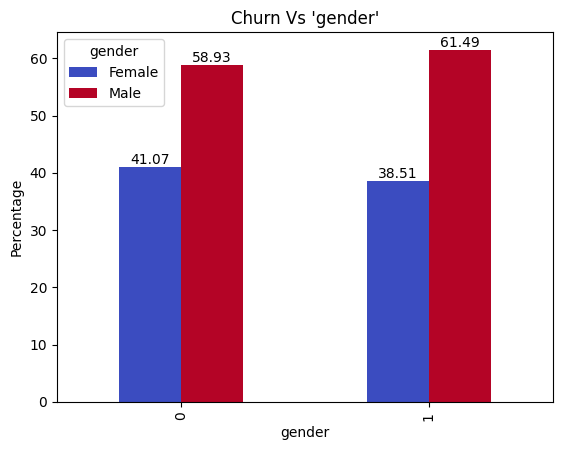

<Figure size 1400x800 with 0 Axes>

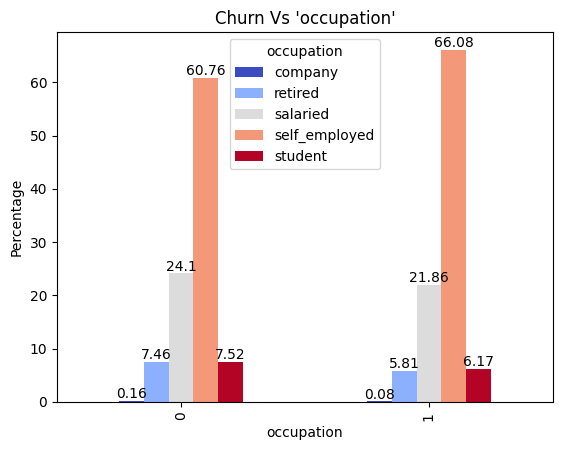

<Figure size 1400x800 with 0 Axes>

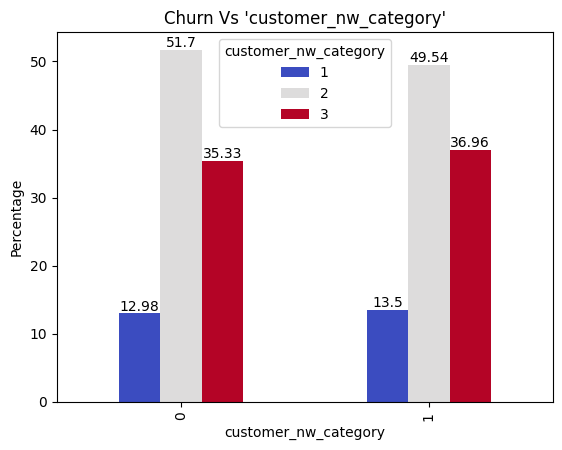

<Figure size 1400x800 with 0 Axes>

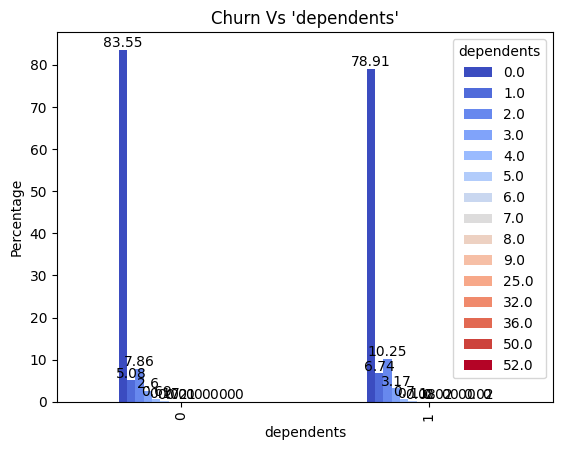

In [43]:
for col in cat_cols:
    plot_barplt_with_target(customers, col)

### insight - 4
- 18.53% customer closed their account
    - in total sample, 59% is Male and 40% is Female
    - Out of churned customers, 61% is male and 38% is female

- Maximum customers are self_emplyed (61%)
    - 66% self-employes customers closed their account, followed by salaried. Lowest is company

- 51.29 customers in net-worth category-2, followed by 35.62% in category-3 and 13% in category-1
    - 49% of category 2 churned, followed by category 3 and category 1

- Top 5 cities from where customers closed their account are 1020(11.6%), 1096(6.22%), 146(4.26%), 409(4.26%), 834(3.95%)

- Top 5 branch code from where customers closed their account are 6(0.67%), 79(0.49%), 47(0.46%), 60(0.46%), 19(0.42%)

- 81% customers who closed their account has 0 dependents

### Bivariant Analysis - Numerical features

In [44]:
def plot_histogram_with_target(dataset, column, bins=30):
    min_value = dataset[column].min()
    max_value = dataset[column].max()
    
    print(f"Column: {column}: min value : {min_value}, max value: {max_value}")
    fig, ax = plt.subplots(1,2,figsize=(14,5))
    sns.histplot(data=dataset, x=column, hue=target, bins=bins, kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {column} vs {target}")
    ax[0].set_xlim(min_value, max_value)
    ax[0].set_xlabel(column)
    

    sns.boxplot(data=dataset, x=target, y=column, ax=ax[1])
    ax[1].set_title(f"Boxplot of {column} vs {target}")
    plt.show()

Column: age: min value : 1, max value: 90


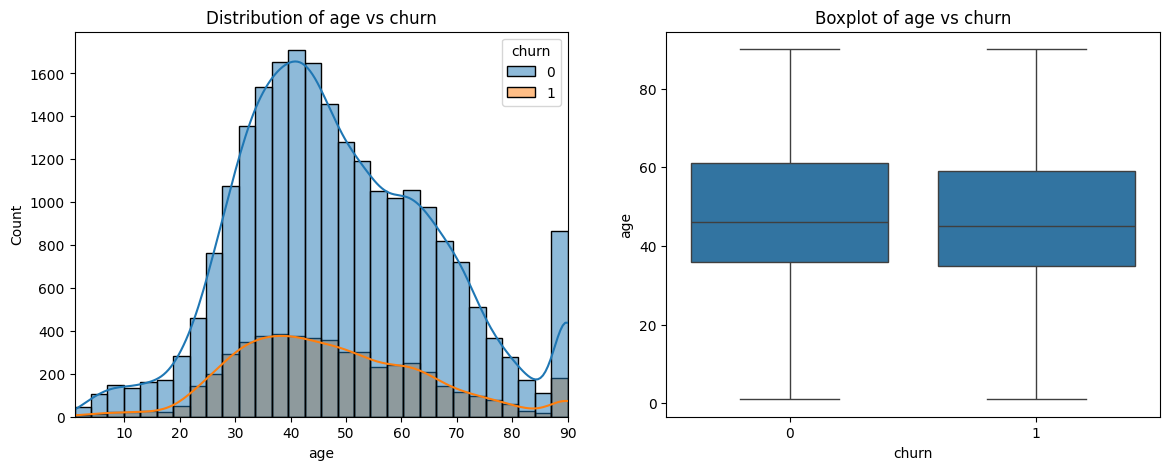

Column: vintage: min value : 73, max value: 2476


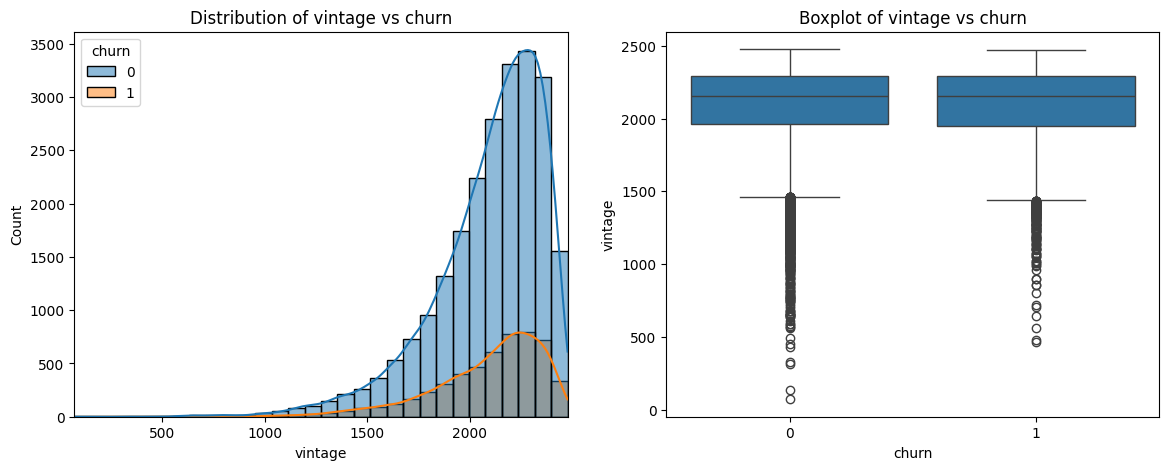

In [45]:
customers["churn"]
for col in ["age","vintage"]:
    plot_histogram_with_target(customers, col)

### Insight - 5
- __Most of the customers who closed the account are between 35 and 59 of age__
- __The duration of the customer's relationship with the company between 1949 and 2155 are the one who closed the account.__

P(churn | high balance)

P(churn | low balance)

In [46]:
for col in numerical_columns:
    low_balance_threshold = customers[col].quantile(0.25)
    customers[f"{col}_group"] = customers[col].apply(lambda x: "low" if x < low_balance_threshold else "high")

    low_balance_customer = customers[customers[f"{col}_group"] == "low"]
    p_low_balance_churn = round(low_balance_customer["churn"].mean(),2)

    high_balance_customer = customers[customers[f"{col}_group"] == "high"]
    p_high_balance_churn = round(high_balance_customer["churn"].mean(), 2)

    if p_low_balance_churn > p_high_balance_churn:
        print(f"customers with low {col} has {round(p_low_balance_churn/p_high_balance_churn, 1)} times more probability to churn")
    else:
        print(f"customers with high {col} has {round(p_high_balance_churn/p_low_balance_churn, 1)} times more probability to churn")


customers with low vintage has 1.1 times more probability to churn
customers with low age has 1.1 times more probability to churn
customers with low current_balance has 3.6 times more probability to churn
customers with low previous_month_end_balance has 1.7 times more probability to churn
customers with high average_monthly_balance_prevQ has 1.1 times more probability to churn
customers with low average_monthly_balance_prevQ2 has 1.4 times more probability to churn
customers with high current_month_credit has 1.1 times more probability to churn
customers with high previous_month_credit has 1.1 times more probability to churn
customers with high current_month_debit has 1.9 times more probability to churn
customers with high previous_month_debit has 1.8 times more probability to churn
customers with low current_month_balance has 2.2 times more probability to churn
customers with low previous_month_balance has 1.1 times more probability to churn


### insight - 6 

- __customers with low current balance are 3.5 times more likely to churn__
- __customers with low current_month balance has 2.2 time more probability to churn__

In [47]:
# for col in number_columns:
#     balance_threshold = customers[col].quantile(0.25)
#     customers[f"{col}_group"] = customers[col].apply(lambda x: "low" if x < balance_threshold else "high")
#     plot_barplt_with_target(customers, f"{col}_group")

### Corelation

In [48]:
customers["dependents"] = customers["dependents"].fillna(0)
customers["city"] = customers["city"].fillna(0)

In [49]:
print(np.corrcoef(customers[numerical_columns]))

[[1.         0.654485   0.55124059 ... 0.65923853 0.97715838 0.73262777]
 [0.654485   1.         0.76892216 ... 0.65651159 0.77328182 0.93855046]
 [0.55124059 0.76892216 1.         ... 0.69863018 0.6031124  0.6236351 ]
 ...
 [0.65923853 0.65651159 0.69863018 ... 1.         0.74662901 0.69313648]
 [0.97715838 0.77328182 0.6031124  ... 0.74662901 1.         0.8459215 ]
 [0.73262777 0.93855046 0.6236351  ... 0.69313648 0.8459215  1.        ]]


In [50]:
customers[numerical_features].corr()

,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
vintage,1.000000,0.006220,0.004560,0.004183,-0.001154,0.003512,0.000031,-0.000669,-0.002054,-0.001759,-0.004617,-0.000169,-0.004978,-0.006760,-0.000550,-0.002208,-0.004769
age,0.006220,1.000000,0.001261,0.016692,-0.076532,-0.058990,0.054346,0.058342,0.061708,0.059607,0.023840,0.029961,0.027702,0.033296,0.057662,0.060297,-0.020012
dependents,0.004560,0.001261,1.000000,0.004801,0.007917,-0.001704,-0.003838,-0.002181,-0.001786,-0.001967,0.003542,0.025848,0.008225,0.030746,-0.002769,-0.001672,0.029335
city,0.004183,0.016692,0.004801,1.000000,-0.003352,-0.071830,-0.003366,-0.001974,-0.004190,-0.006292,0.004955,0.010128,0.002171,0.007385,-0.003524,-0.003834,-0.003783
customer_nw_category,-0.001154,-0.076532,0.007917,-0.003352,1.000000,0.235059,-0.058314,-0.059854,-0.059535,-0.047010,-0.025254,-0.072374,-0.035917,-0.071721,-0.058648,-0.059113,0.006551
branch_code,0.003512,-0.058990,-0.001704,-0.071830,0.235059,1.000000,0.000181,0.000214,0.001955,0.001310,-0.013988,-0.023849,-0.016944,-0.017584,0.001031,0.002080,0.035469
current_balance,0.000031,0.054346,-0.003838,-0.003366,-0.058314,0.000181,1.000000,0.947276,0.958307,0.714600,0.030371,0.061754,0.044412,0.081247,0.983412,0.942207,-0.024181
previous_month_end_balance,-0.000669,0.058342,-0.002181,-0.001974,-0.059854,0.000214,0.947276,1.000000,0.970530,0.722998,0.032493,0.114222,0.066329,0.109606,0.974714,0.969605,0.006886
average_monthly_balance_prevQ,-0.002054,0.061708,-0.001786,-0.004190,-0.059535,0.001955,0.958307,0.970530,1.000000,0.763495,0.033639,0.085699,0.060579,0.121272,0.976290,0.994038,0.011960
average_monthly_balance_prevQ2,-0.001759,0.059607,-0.001967,-0.006292,-0.047010,0.001310,0.714600,0.722998,0.763495,1.000000,0.036271,0.062264,0.045239,0.102519,0.725826,0.736635,0.018376


<Axes: >

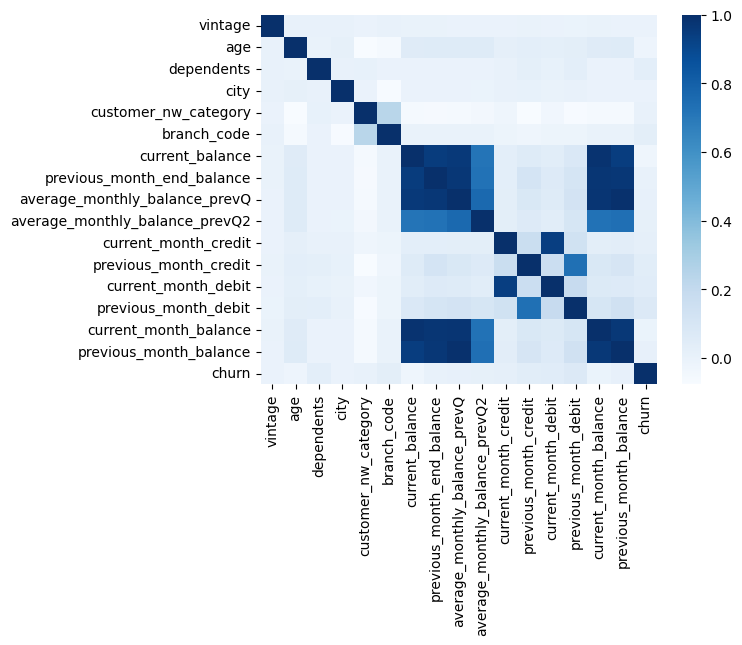

In [51]:
sns.heatmap(customers[numerical_features].corr(), cmap='Blues')

### Last Transaction Vs. Churn

In [52]:
customers["month"] = customers["last_transaction"].dt.month
customers["year"] = customers["last_transaction"].dt.year

In [53]:
customers.groupby("year")["year"].value_counts()

year
2018.0        3
2019.0    25156
Name: count, dtype: int64

In [83]:
customers[customers["churn"] == 1][["year","month"]].value_counts()

year    month
2019.0  12.0     2533
        11.0      874
        10.0      510
        9.0       280
        8.0       193
        7.0       149
        6.0       105
        5.0        86
        3.0        72
        4.0        64
        1.0        53
        2.0        42
Name: count, dtype: int64

In [66]:
customers["days_since_last_transaction"] = (pd.Timestamp.today() - customers["last_transaction"]).dt.days
customers.head()

,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,...,average_monthly_balance_prevQ2_group,current_month_credit_group,previous_month_credit_group,current_month_debit_group,previous_month_debit_group,current_month_balance_group,previous_month_balance_group,month,year,days_since_last_transaction
0,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,...,low,low,low,low,low,low,low,5.0,2019.0,2488.0
1,2348,35,Male,0.0,self_employed,0.0,2,3214,5390.37,8704.66,...,high,high,high,high,high,high,high,11.0,2019.0,2324.0
2,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,...,high,high,high,high,high,high,high,NaN,NaN,NaN
3,2329,90,NaN,0.0,self_employed,1020.0,2,582,2291.91,2291.91,...,low,high,high,high,high,high,low,8.0,2019.0,2411.0
4,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,...,high,high,high,high,high,low,low,11.0,2019.0,2322.0


<Axes: xlabel='churn', ylabel='days_since_last_transaction'>

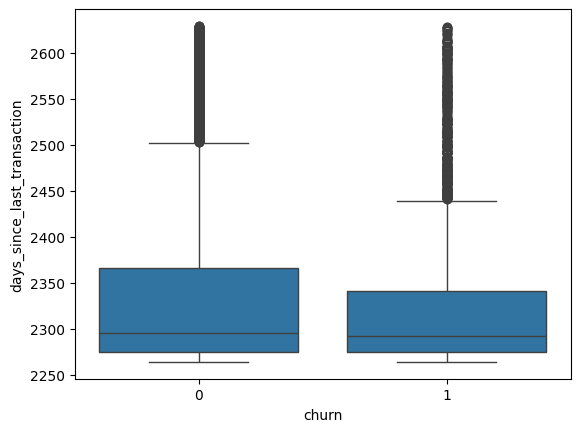

In [67]:
sns.boxplot(data=customers, x="churn", y="days_since_last_transaction")

In [58]:
days_since_last_transaction_median = customers["days_since_last_transaction"].median()
customers["days_since_last_transaction"] = customers["days_since_last_transaction"].fillna(days_since_last_transaction_median)

In [68]:
churned_customers = customers[customers["churn"] == 1]
q1_churned, q2_churned, q3_churned = stat.quantiles(churned_customers["days_since_last_transaction"])
print(q1_churned,q2_churned,q3_churned)

not_churned_customers = customers[customers["churn"] == 0]
not_churned_customers.head()
q1_not_churned, q2_not_churned, q3_not_churned = stat.quantiles(not_churned_customers["days_since_last_transaction"])
print(q1_not_churned,q2_not_churned,q3_not_churned)

churned_customers["days_since_last_transaction"].max()

2264.0 2328.0 2264.0
2308.0 2277.5 2267.75


np.float64(2628.0)

In [79]:
print(customers[customers["days_since_last_transaction"] > q3_churned]["days_since_last_transaction"].count())
print(customers[customers["days_since_last_transaction"] > q3_not_churned]["days_since_last_transaction"].count())

23487
22516


In [78]:
print(customers[customers["days_since_last_transaction"] < q1_churned]["days_since_last_transaction"].count())
print(customers[customers["days_since_last_transaction"] < q1_not_churned]["days_since_last_transaction"].count())

0
14428


### Insight - 7

- __3 samples are from 2018 and 25156 are from 2019__

- __Long period of inactivity increases churn risk__

### Summary

1. __The customer dataset contains 28,382 samples and 20 features, only 5 columns contains null values ('gender', 'dependents', 'occupation', 'city', 'last_transaction')__

    - 'gender' has 525 null values, 1.85% of total samples
    - 'dependents' has 2463 null values, 8.68% of total samples
    - 'occupation' has 80 null values, 0.28% of total samples
    - 'city' has 803 null values, 2.83% of total samples
    - 'last_transaction' has 3223 null values, 11.36% of total samples

2. __numerical features contains high number of outliers except 'age'__
    - 'vintage',
    - 'dependents',
    - 'current_balance',
    - 'previous_month_end_balance',
    - 'average_monthly_balance_prevQ',
    - 'average_monthly_balance_prevQ2',
    - 'current_month_credit',
    - 'previous_month_credit',
    -  'current_month_debit',
    - 'previous_month_debit',
    -  'current_month_balance',
    -  'previous_month_balance'

3. __Category feature distribution__
    - 'gender'- 59.4% is male and 40.59 % is female
    - 'occupation' - 61% is self-employed
    - 'customer_nw_category' - 51.29% in category 2, followed by 35.62% in category-3 and 13% in category-1
    
    - 'city' 
        - 12.26% customers are from 1020 city
        - 7.1% customers are from 1096 city
        - 4.7% customers are from 409 city
        - 4.55% customers are from 146 city
        - 4.01% customers are from 834 city

    - 'branch code'
        - 0.51% customers are from branch-code 19
        - 0.5% customers are from branch-code 6
        - 0.45% customers are from branch-code 60
        - 0.39% customers are from branch-code 16
        - 0.38% customers are from branch-code 8
    
    - 'dependents'
        -82% customers has 0 dependents

4. 18.53% customer closed their account
    - Out of churned customers, 61% is male and 38% is female
    - 66% are self-employed customers, followed by salaried. Lowest is company
    - 49% of are from category-2, followed by category-3 and category-1
    - Top 5 cities from where customers closed their account are 1020(11.6%), 1096(6.22%), 146(4.26%), 409(4.26%), 834(3.95%)
    - Top 5 branch code from where customers closed their account are 6(0.67%), 79(0.49%), 47(0.46%), 60(0.46%), 19(0.42%)
    - 81% customers who closed their account has 0 dependents


5. Most of the customers who closed the account are between 35 and 59 of age
- The duration of the customer's relationship with the company between 1949 and 2155 are the one who closed the account.

6. __customers with low current balance are 3.5 times more likely to churn__
- __customers with low current_month balance has 2.2 time more probable to churn__

7. __3 samples are from 2018 and 25156 are from 2019__
- __Long period of inactivity increases churn risk__